## some explaratory data analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your prices file
file_path = r"c:/Users/cadem/Prosperity4/data/data/prices_round_0_day_-1.csv"
prices = pd.read_csv(file_path, sep=';')

# Keep only the two products you want
prices = prices[prices['product'].isin(['TOMATOES', 'EMERALDS'])].copy()

# Sort
prices = prices.sort_values(['product', 'timestamp']).reset_index(drop=True)

# Split into separate dataframes
tomatoes_prices = prices[prices['product'] == 'TOMATOES'].copy().reset_index(drop=True)
emeralds_prices = prices[prices['product'] == 'EMERALDS'].copy().reset_index(drop=True)

print(tomatoes_prices.head())
print(emeralds_prices.head())

FileNotFoundError: [Errno 2] No such file or directory: 'c:/Users/cadem/Prosperity4/data/data/prices_round_0_day_-1.csv'

## mid price

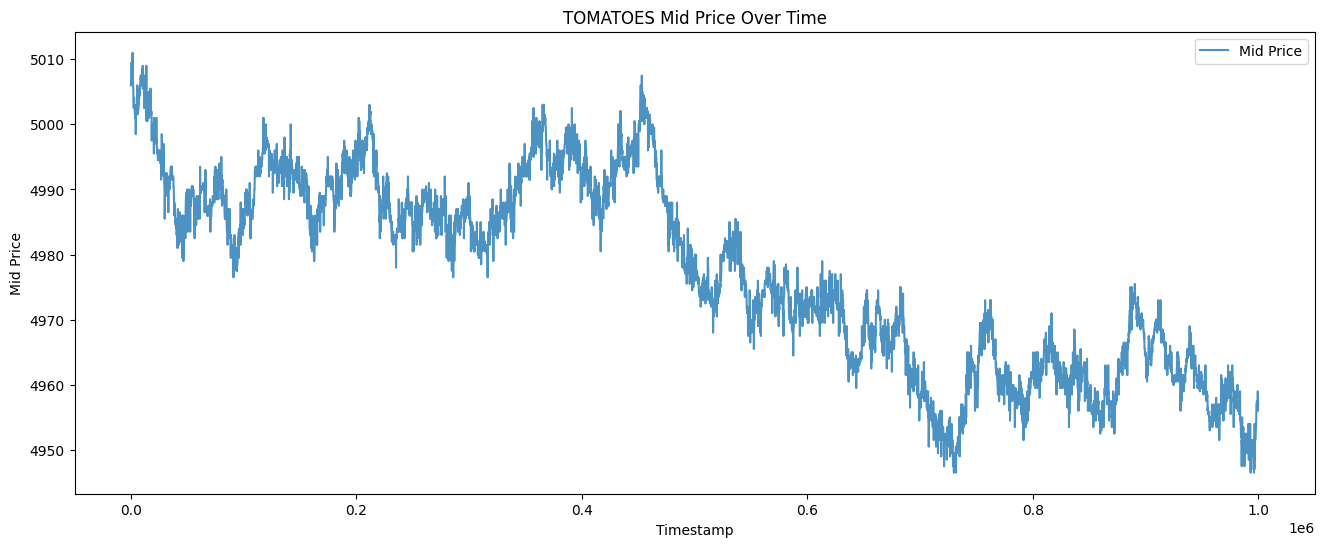

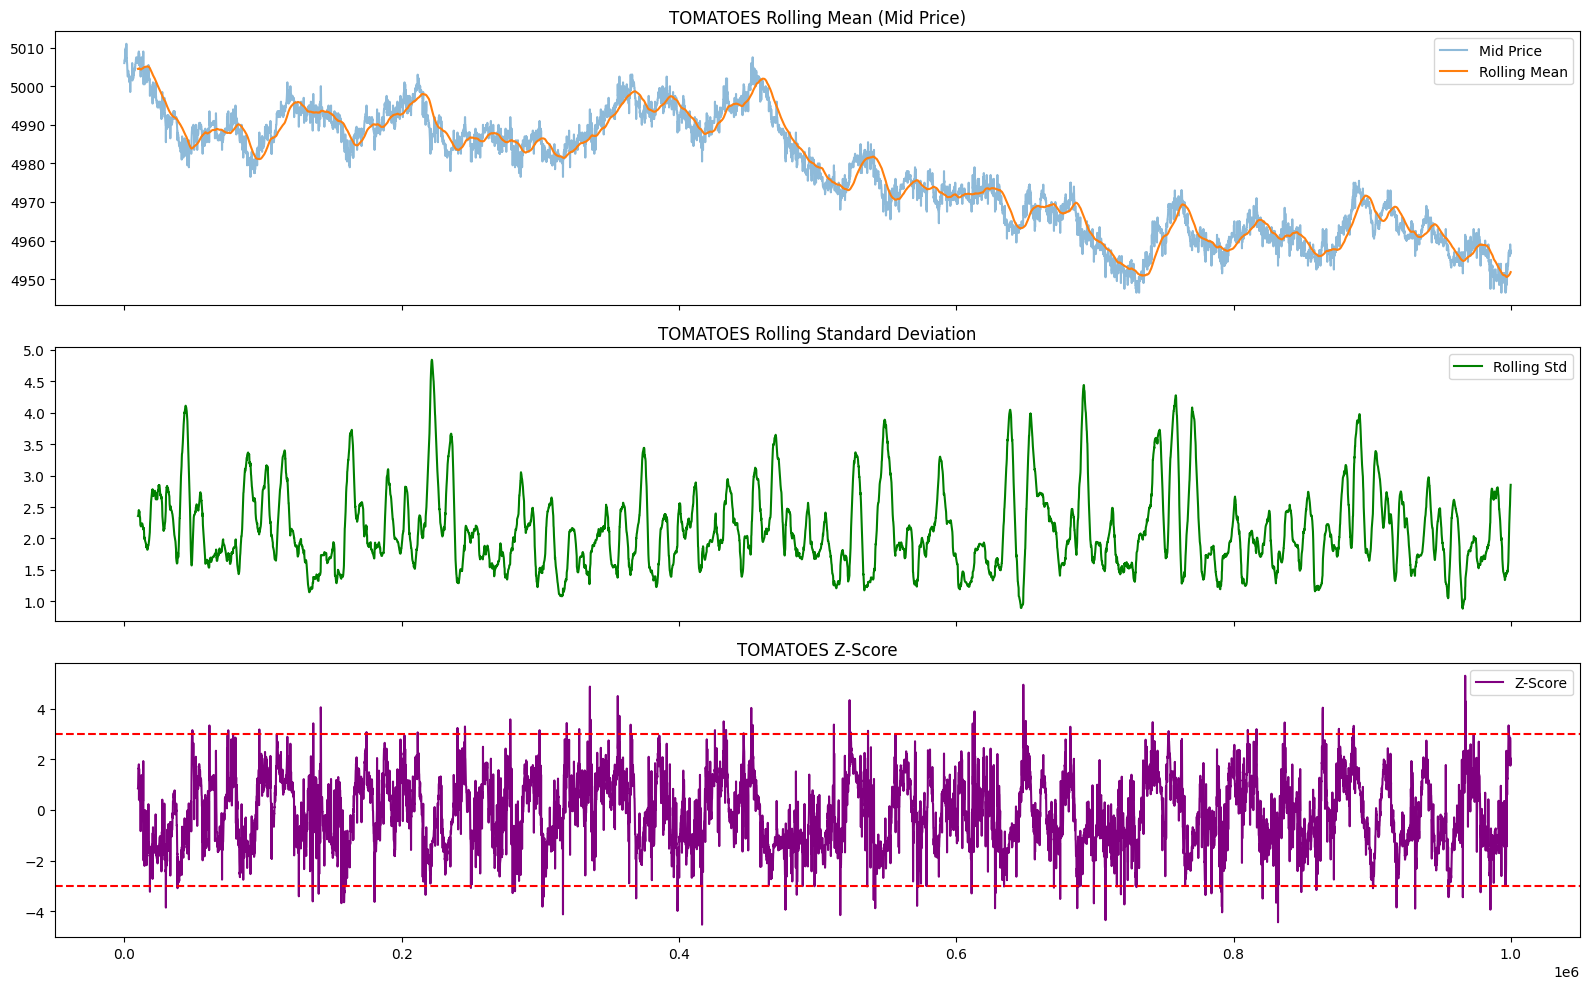

In [ ]:
# Mid price over time
plt.figure(figsize=(16, 6))
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['mid_price'], label='Mid Price', alpha=0.8)
plt.title('TOMATOES Mid Price Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

# Rolling stats
WINDOW = 100

tomatoes_prices['rolling_mean'] = tomatoes_prices['mid_price'].rolling(WINDOW).mean()
tomatoes_prices['rolling_std'] = tomatoes_prices['mid_price'].rolling(WINDOW).std()
tomatoes_prices['z_score'] = (
    (tomatoes_prices['mid_price'] - tomatoes_prices['rolling_mean']) 
    / tomatoes_prices['rolling_std']
)

fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axs[0].plot(tomatoes_prices['timestamp'], tomatoes_prices['mid_price'], label='Mid Price', alpha=0.5)
axs[0].plot(tomatoes_prices['timestamp'], tomatoes_prices['rolling_mean'], label='Rolling Mean')
axs[0].set_title('TOMATOES Rolling Mean (Mid Price)')
axs[0].legend()

axs[1].plot(tomatoes_prices['timestamp'], tomatoes_prices['rolling_std'], label='Rolling Std', color='green')
axs[1].set_title('TOMATOES Rolling Standard Deviation')
axs[1].legend()

axs[2].plot(tomatoes_prices['timestamp'], tomatoes_prices['z_score'], label='Z-Score', color='purple')
axs[2].axhline(3, color='r', linestyle='--')
axs[2].axhline(-3, color='r', linestyle='--')
axs[2].set_title('TOMATOES Z-Score')
axs[2].legend()

plt.tight_layout()
plt.show()

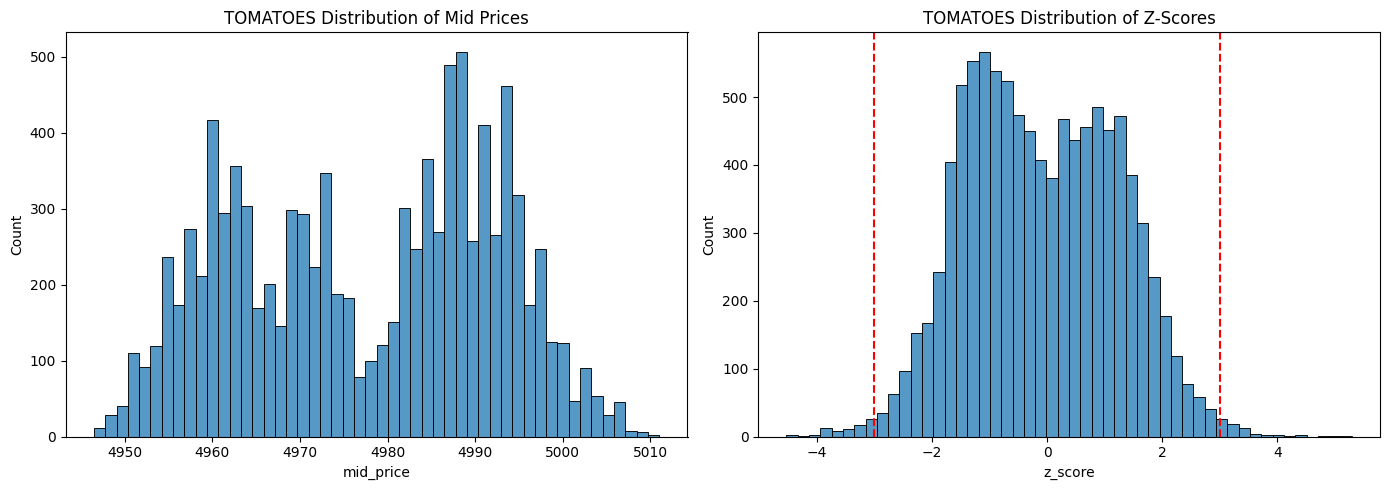

In [ ]:
# Distributions
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(tomatoes_prices['mid_price'], bins=50, ax=axs[0])
axs[0].set_title("TOMATOES Distribution of Mid Prices")

sns.histplot(tomatoes_prices['z_score'].dropna(), bins=50, ax=axs[1])
axs[1].axvline(3, color='r', linestyle='--')
axs[1].axvline(-3, color='r', linestyle='--')
axs[1].set_title("TOMATOES Distribution of Z-Scores")

plt.tight_layout()
plt.show()

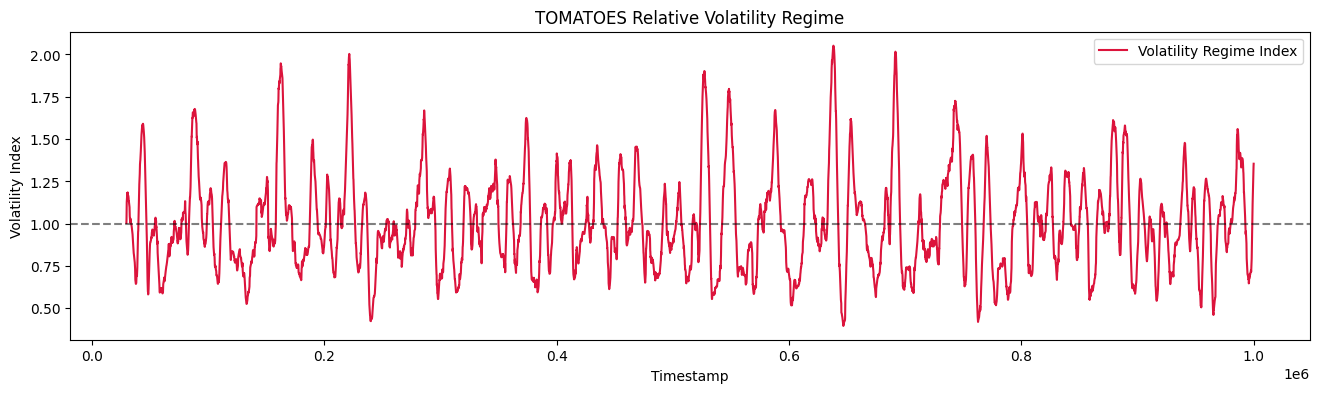

In [ ]:
# Volatility regime
VOL_WINDOW = 200
tomatoes_prices['volatility_regime'] = (
    tomatoes_prices['rolling_std'] 
    / tomatoes_prices['rolling_std'].rolling(VOL_WINDOW).mean()
)

plt.figure(figsize=(16, 4))
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['volatility_regime'],
         label='Volatility Regime Index', color='crimson')
plt.axhline(1, linestyle='--', color='black', alpha=0.5)
plt.title('TOMATOES Relative Volatility Regime')
plt.xlabel('Timestamp')
plt.ylabel('Volatility Index')
plt.legend()
plt.show()

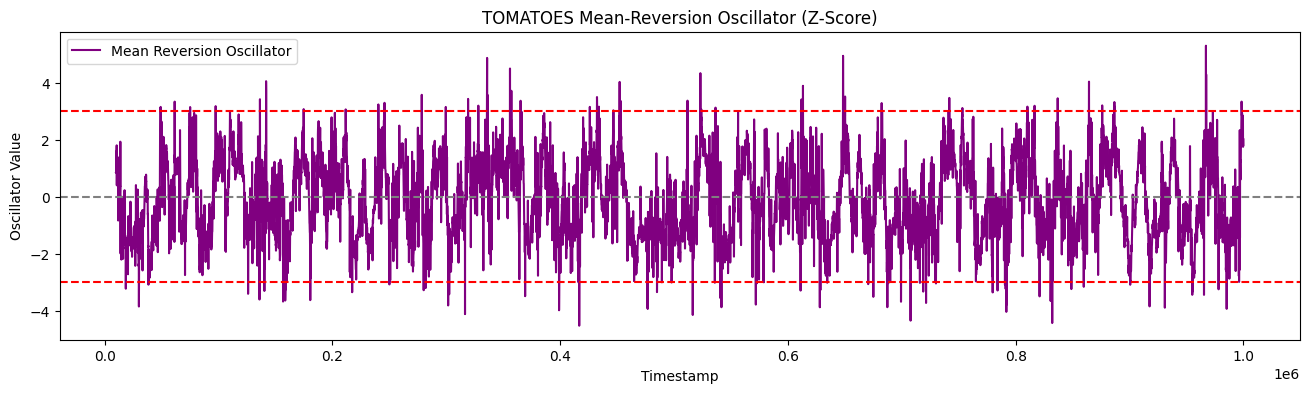

In [ ]:
# Mean-reversion oscillator
tomatoes_prices['oscillator'] = (
    (tomatoes_prices['mid_price'] - tomatoes_prices['rolling_mean']) 
    / tomatoes_prices['rolling_std']
)

plt.figure(figsize=(16, 4))
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['oscillator'],
         label='Mean Reversion Oscillator', color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.title('TOMATOES Mean-Reversion Oscillator (Z-Score)')
plt.xlabel('Timestamp')
plt.ylabel('Oscillator Value')
plt.legend()
plt.show()

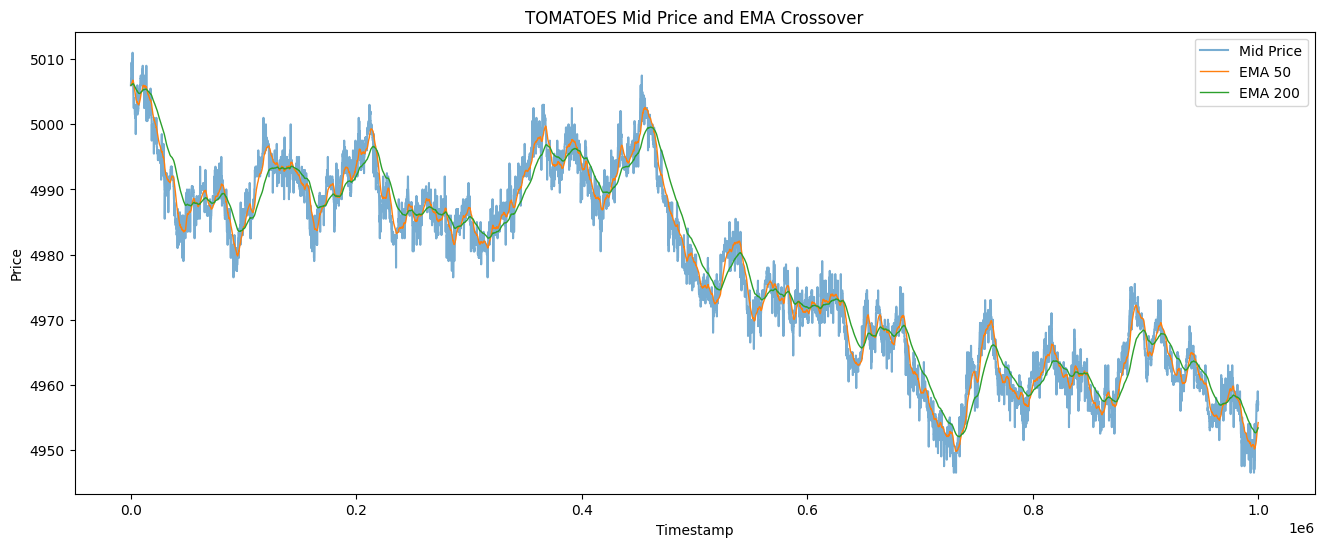

In [ ]:
# EMA crossover
SHORT_WINDOW = 50
LONG_WINDOW = 200

tomatoes_prices['ema_short'] = tomatoes_prices['mid_price'].ewm(span=SHORT_WINDOW, adjust=False).mean()
tomatoes_prices['ema_long'] = tomatoes_prices['mid_price'].ewm(span=LONG_WINDOW, adjust=False).mean()
tomatoes_prices['ema_diff'] = tomatoes_prices['ema_short'] - tomatoes_prices['ema_long']

plt.figure(figsize=(16, 6))
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['ema_short'], label=f'EMA {SHORT_WINDOW}', linewidth=1)
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['ema_long'], label=f'EMA {LONG_WINDOW}', linewidth=1)
plt.title('TOMATOES Mid Price and EMA Crossover')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.show()

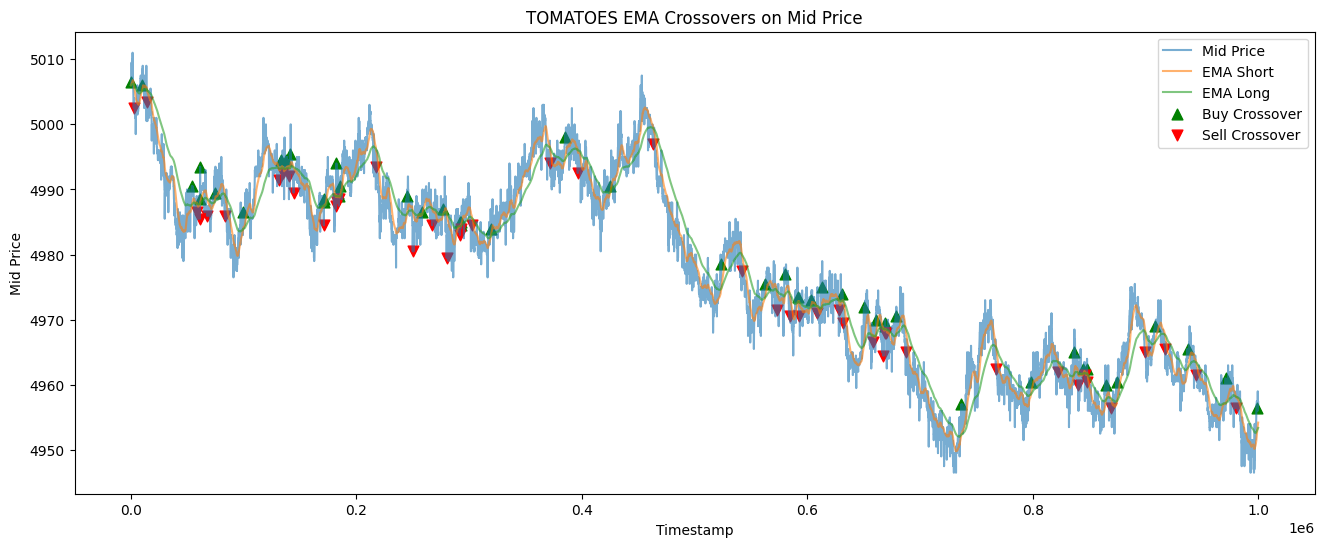

In [ ]:
# Detect crossover points
tomatoes_prices['signal'] = 0
tomatoes_prices.loc[tomatoes_prices['ema_diff'] > 0, 'signal'] = 1
tomatoes_prices.loc[tomatoes_prices['ema_diff'] < 0, 'signal'] = -1

tomatoes_prices['signal_shift'] = tomatoes_prices['signal'].shift(1)
tomatoes_prices['crossover'] = tomatoes_prices['signal'] != tomatoes_prices['signal_shift']

crossovers = tomatoes_prices[(tomatoes_prices['crossover']) & (tomatoes_prices['signal'] != 0)]

buy_cross = crossovers[crossovers['signal'] == 1]
sell_cross = crossovers[crossovers['signal'] == -1]

plt.figure(figsize=(16, 6))
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['ema_short'], label='EMA Short', alpha=0.6)
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['ema_long'], label='EMA Long', alpha=0.6)
plt.scatter(buy_cross['timestamp'], buy_cross['mid_price'], color='green', label='Buy Crossover', marker='^', s=60)
plt.scatter(sell_cross['timestamp'], sell_cross['mid_price'], color='red', label='Sell Crossover', marker='v', s=60)
plt.title('TOMATOES EMA Crossovers on Mid Price')
plt.xlabel('Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

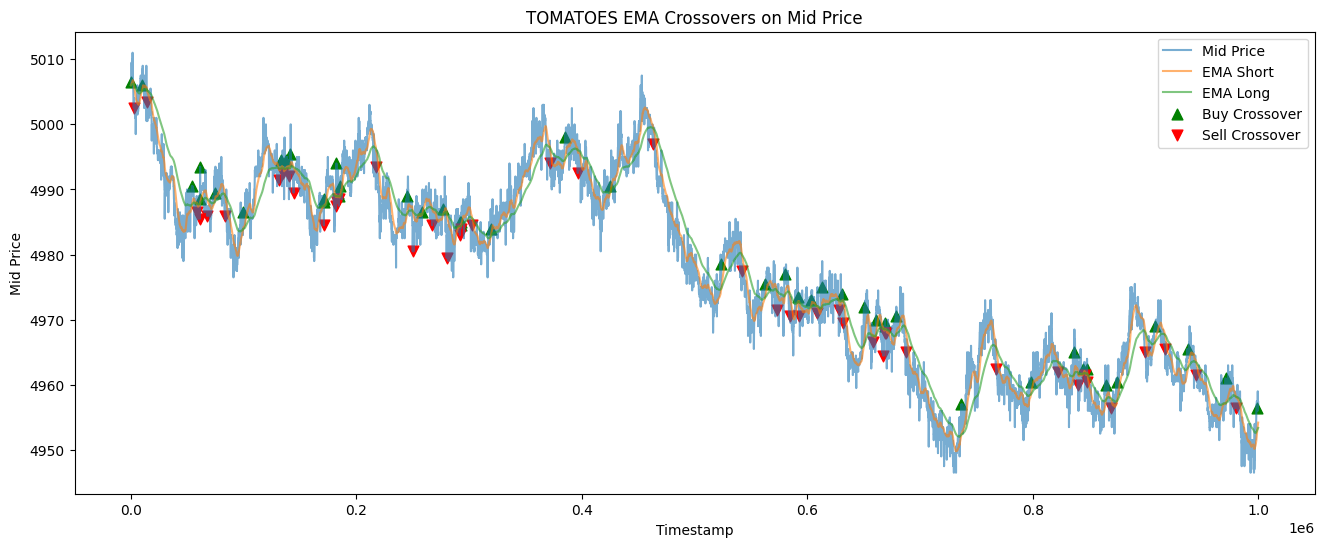

In [ ]:
# Detect crossover points
tomatoes_prices['signal'] = 0
tomatoes_prices.loc[tomatoes_prices['ema_diff'] > 0, 'signal'] = 1
tomatoes_prices.loc[tomatoes_prices['ema_diff'] < 0, 'signal'] = -1

tomatoes_prices['signal_shift'] = tomatoes_prices['signal'].shift(1)
tomatoes_prices['crossover'] = tomatoes_prices['signal'] != tomatoes_prices['signal_shift']

crossovers = tomatoes_prices[(tomatoes_prices['crossover']) & (tomatoes_prices['signal'] != 0)]

buy_cross = crossovers[crossovers['signal'] == 1]
sell_cross = crossovers[crossovers['signal'] == -1]

plt.figure(figsize=(16, 6))
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['ema_short'], label='EMA Short', alpha=0.6)
plt.plot(tomatoes_prices['timestamp'], tomatoes_prices['ema_long'], label='EMA Long', alpha=0.6)
plt.scatter(buy_cross['timestamp'], buy_cross['mid_price'], color='green', label='Buy Crossover', marker='^', s=60)
plt.scatter(sell_cross['timestamp'], sell_cross['mid_price'], color='red', label='Sell Crossover', marker='v', s=60)
plt.title('TOMATOES EMA Crossovers on Mid Price')
plt.xlabel('Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

## Emeralds

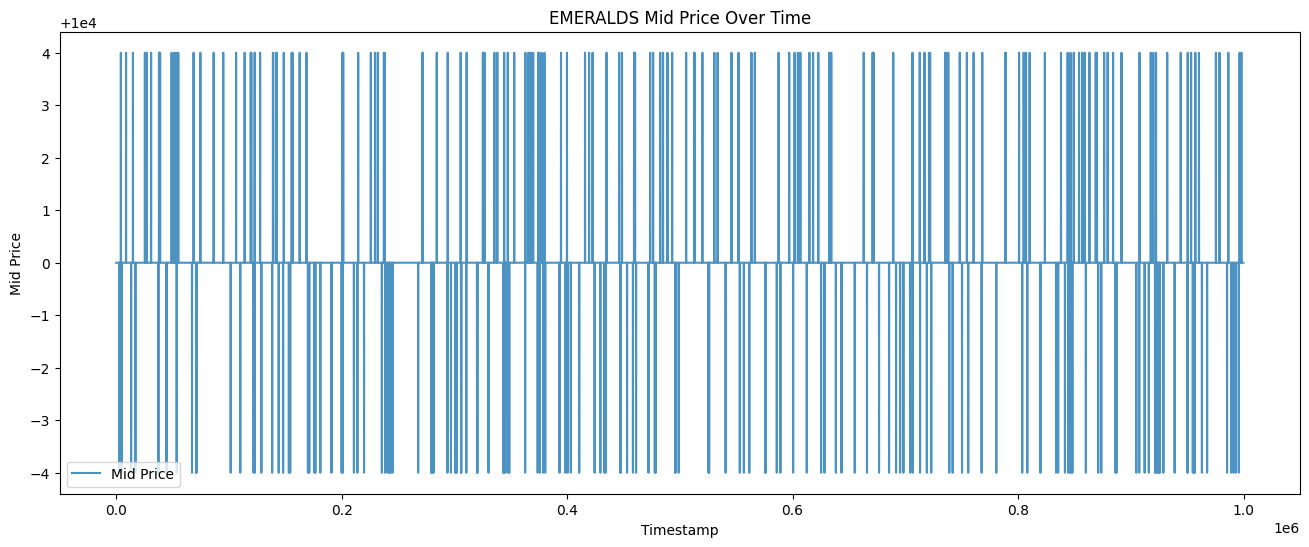

In [ ]:
# Mid price over time
plt.figure(figsize=(16, 6))
plt.plot(emeralds_prices['timestamp'], emeralds_prices['mid_price'], label='Mid Price', alpha=0.8)
plt.title('EMERALDS Mid Price Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

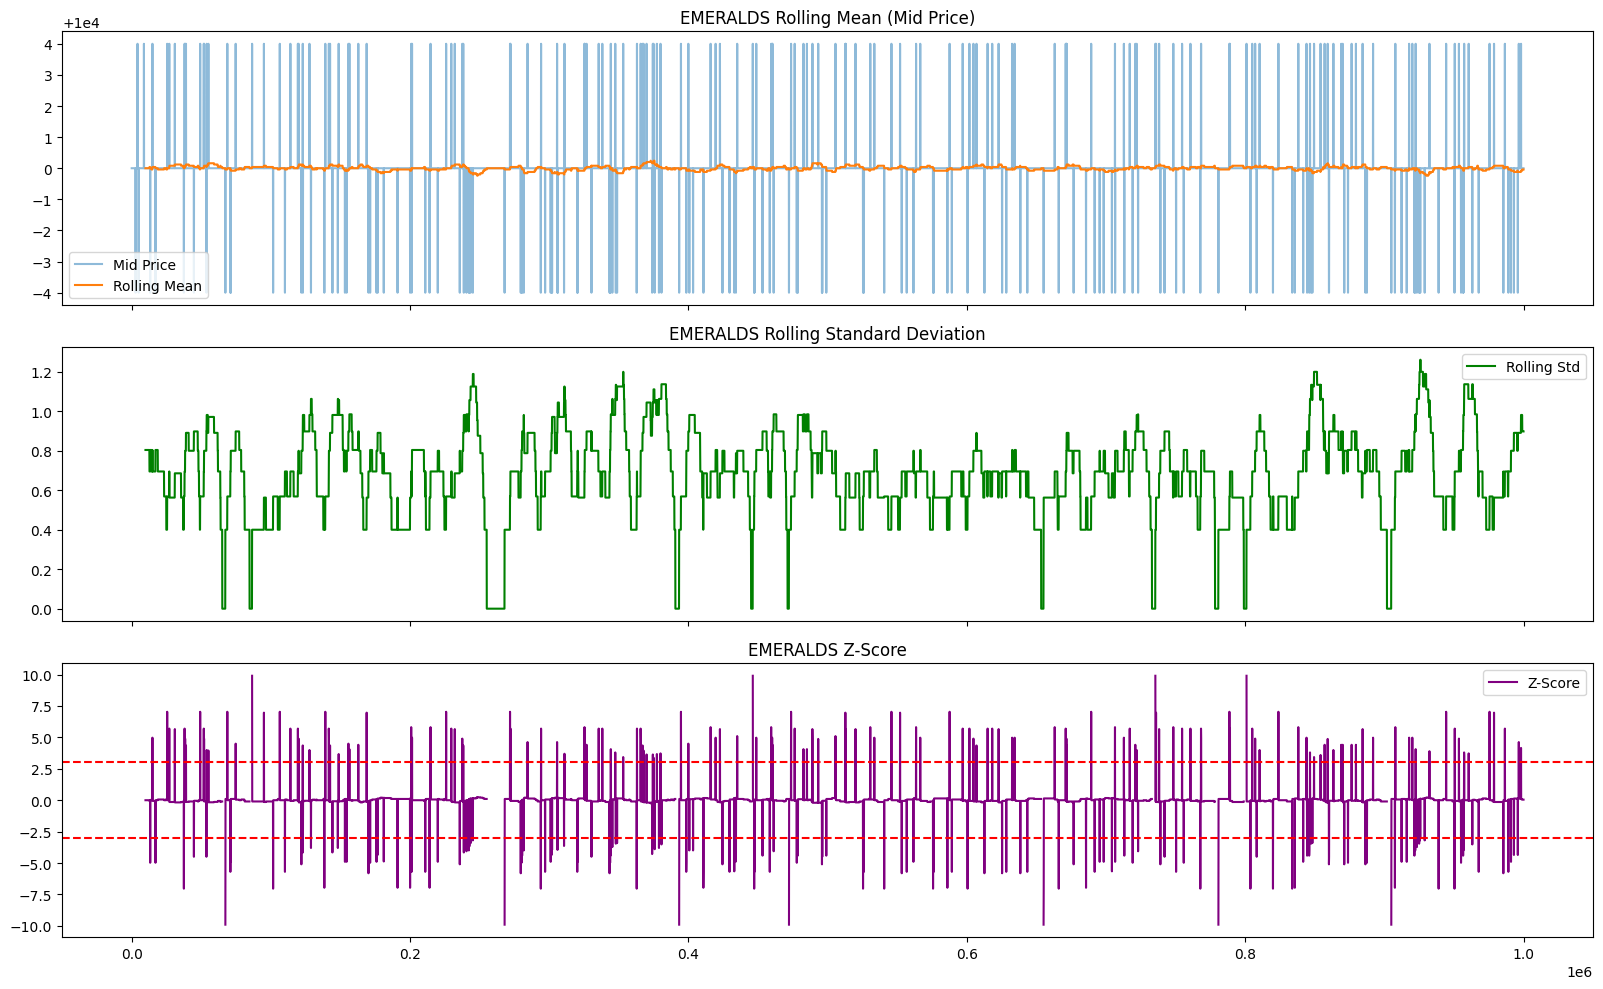

In [ ]:
# Rolling stats
WINDOW = 100

emeralds_prices['rolling_mean'] = emeralds_prices['mid_price'].rolling(WINDOW).mean()
emeralds_prices['rolling_std'] = emeralds_prices['mid_price'].rolling(WINDOW).std()
emeralds_prices['z_score'] = (
    (emeralds_prices['mid_price'] - emeralds_prices['rolling_mean']) 
    / emeralds_prices['rolling_std']
)

fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axs[0].plot(emeralds_prices['timestamp'], emeralds_prices['mid_price'], label='Mid Price', alpha=0.5)
axs[0].plot(emeralds_prices['timestamp'], emeralds_prices['rolling_mean'], label='Rolling Mean')
axs[0].set_title('EMERALDS Rolling Mean (Mid Price)')
axs[0].legend()

axs[1].plot(emeralds_prices['timestamp'], emeralds_prices['rolling_std'], label='Rolling Std', color='green')
axs[1].set_title('EMERALDS Rolling Standard Deviation')
axs[1].legend()

axs[2].plot(emeralds_prices['timestamp'], emeralds_prices['z_score'], label='Z-Score', color='purple')
axs[2].axhline(3, color='r', linestyle='--')
axs[2].axhline(-3, color='r', linestyle='--')
axs[2].set_title('EMERALDS Z-Score')
axs[2].legend()

plt.tight_layout()
plt.show()

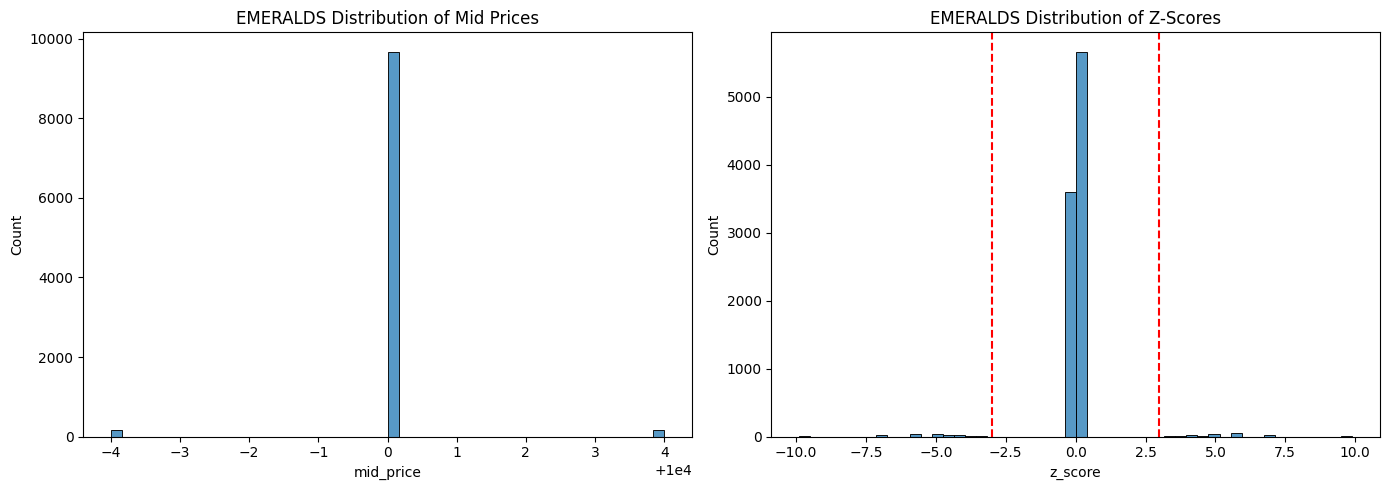

In [ ]:
# Distributions
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(emeralds_prices['mid_price'], bins=50, ax=axs[0])
axs[0].set_title("EMERALDS Distribution of Mid Prices")

sns.histplot(emeralds_prices['z_score'].dropna(), bins=50, ax=axs[1])
axs[1].axvline(3, color='r', linestyle='--')
axs[1].axvline(-3, color='r', linestyle='--')
axs[1].set_title("EMERALDS Distribution of Z-Scores")

plt.tight_layout()
plt.show()

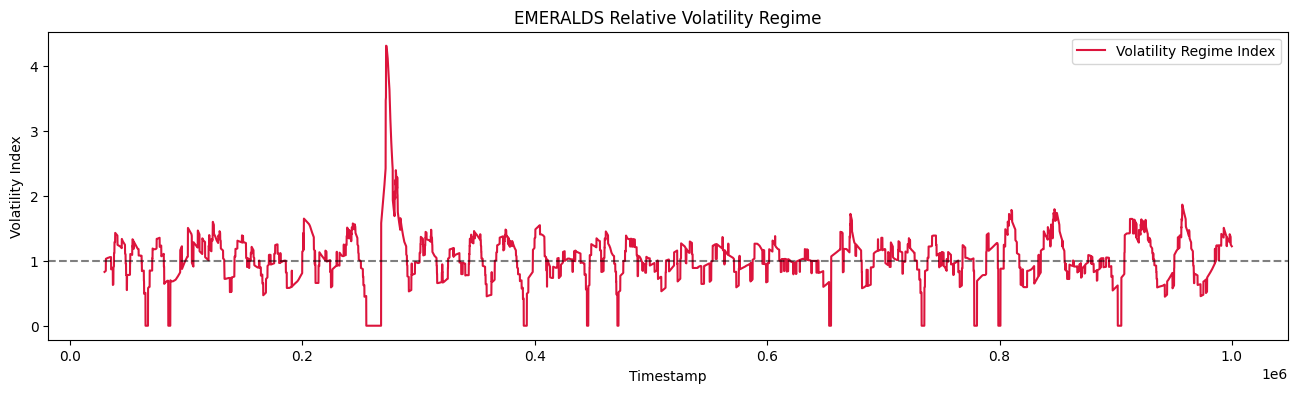

In [ ]:
# Volatility regime
VOL_WINDOW = 200
emeralds_prices['volatility_regime'] = (
    emeralds_prices['rolling_std'] 
    / emeralds_prices['rolling_std'].rolling(VOL_WINDOW).mean()
)

plt.figure(figsize=(16, 4))
plt.plot(emeralds_prices['timestamp'], emeralds_prices['volatility_regime'],
         label='Volatility Regime Index', color='crimson')
plt.axhline(1, linestyle='--', color='black', alpha=0.5)
plt.title('EMERALDS Relative Volatility Regime')
plt.xlabel('Timestamp')
plt.ylabel('Volatility Index')
plt.legend()
plt.show()

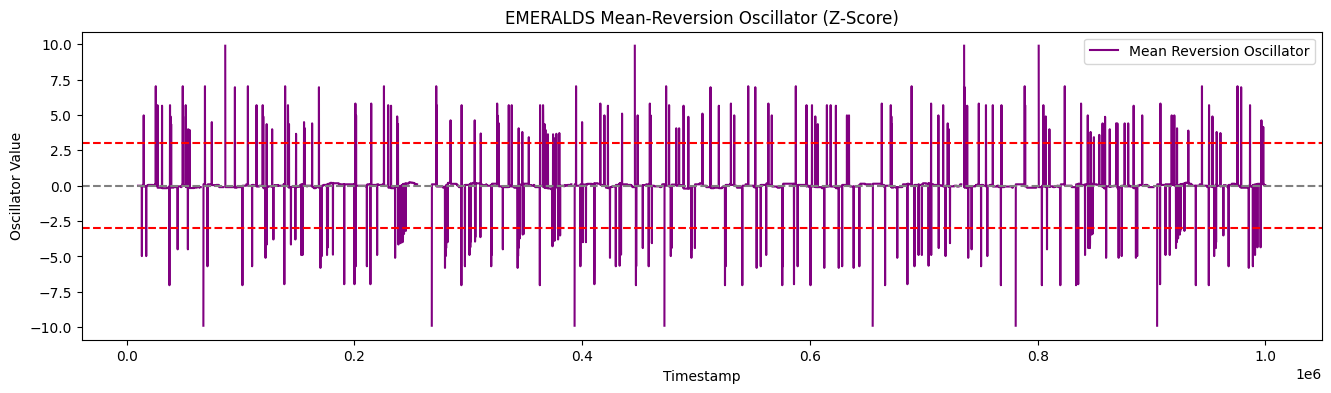

In [ ]:
# Mean-reversion oscillator
emeralds_prices['oscillator'] = (
    (emeralds_prices['mid_price'] - emeralds_prices['rolling_mean']) 
    / emeralds_prices['rolling_std']
)

plt.figure(figsize=(16, 4))
plt.plot(emeralds_prices['timestamp'], emeralds_prices['oscillator'],
         label='Mean Reversion Oscillator', color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.title('EMERALDS Mean-Reversion Oscillator (Z-Score)')
plt.xlabel('Timestamp')
plt.ylabel('Oscillator Value')
plt.legend()
plt.show()

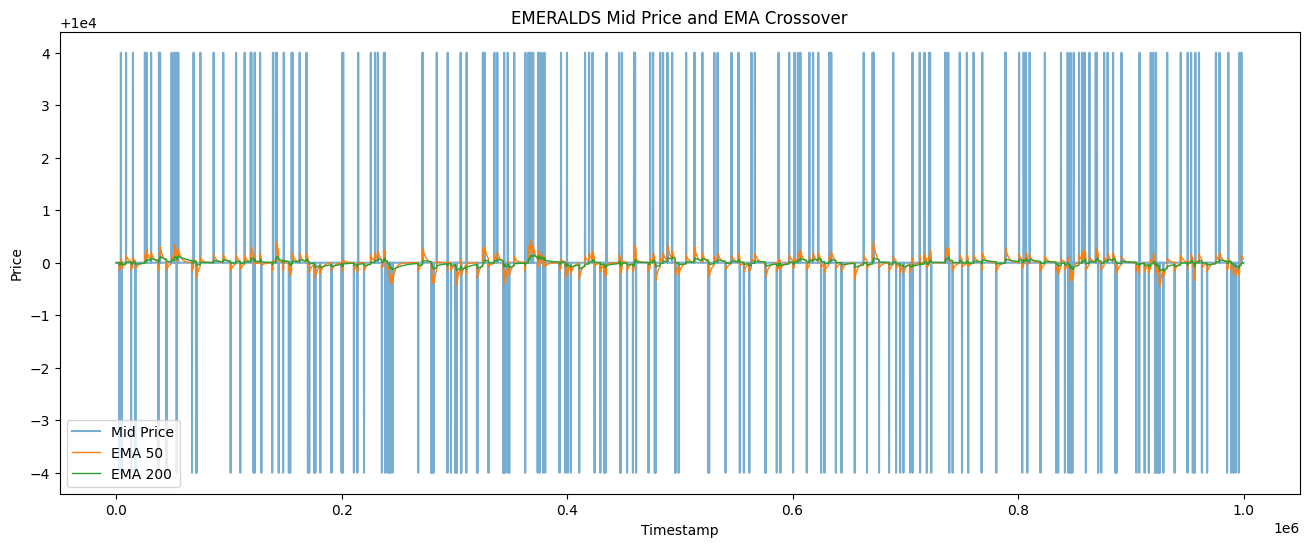

In [ ]:
# EMA crossover
SHORT_WINDOW = 50
LONG_WINDOW = 200

emeralds_prices['ema_short'] = emeralds_prices['mid_price'].ewm(span=SHORT_WINDOW, adjust=False).mean()
emeralds_prices['ema_long'] = emeralds_prices['mid_price'].ewm(span=LONG_WINDOW, adjust=False).mean()
emeralds_prices['ema_diff'] = emeralds_prices['ema_short'] - emeralds_prices['ema_long']

plt.figure(figsize=(16, 6))
plt.plot(emeralds_prices['timestamp'], emeralds_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(emeralds_prices['timestamp'], emeralds_prices['ema_short'], label=f'EMA {SHORT_WINDOW}', linewidth=1)
plt.plot(emeralds_prices['timestamp'], emeralds_prices['ema_long'], label=f'EMA {LONG_WINDOW}', linewidth=1)
plt.title('EMERALDS Mid Price and EMA Crossover')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.show()

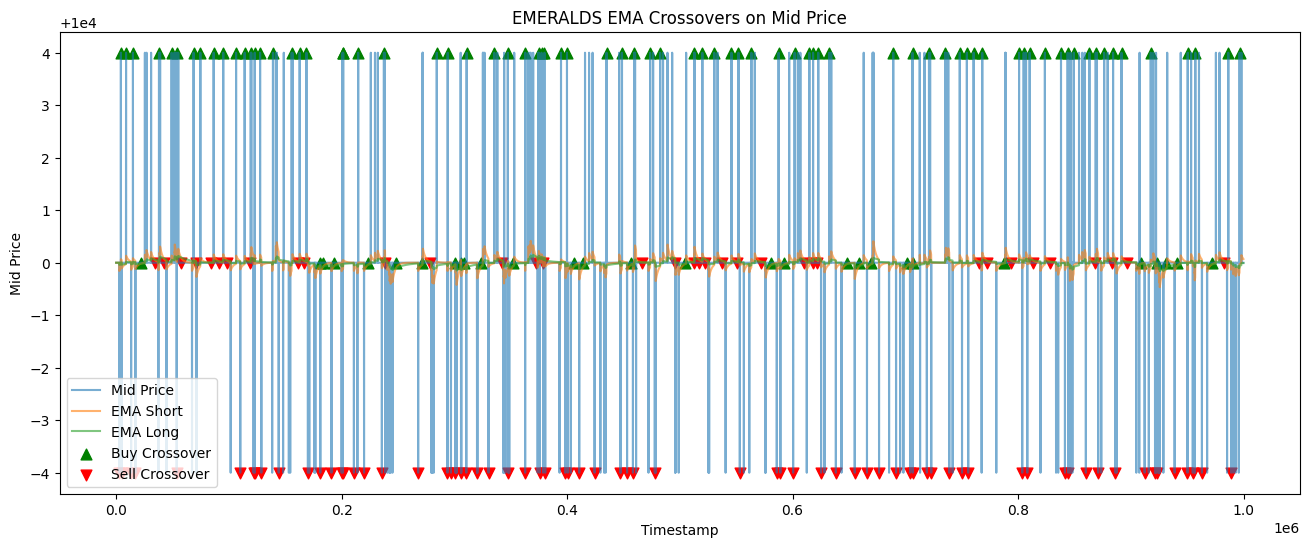

In [ ]:
# Detect crossover points
emeralds_prices['signal'] = 0
emeralds_prices.loc[emeralds_prices['ema_diff'] > 0, 'signal'] = 1
emeralds_prices.loc[emeralds_prices['ema_diff'] < 0, 'signal'] = -1

emeralds_prices['signal_shift'] = emeralds_prices['signal'].shift(1)
emeralds_prices['crossover'] = emeralds_prices['signal'] != emeralds_prices['signal_shift']

crossovers = emeralds_prices[(emeralds_prices['crossover']) & (emeralds_prices['signal'] != 0)]

buy_cross = crossovers[crossovers['signal'] == 1]
sell_cross = crossovers[crossovers['signal'] == -1]

plt.figure(figsize=(16, 6))
plt.plot(emeralds_prices['timestamp'], emeralds_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(emeralds_prices['timestamp'], emeralds_prices['ema_short'], label='EMA Short', alpha=0.6)
plt.plot(emeralds_prices['timestamp'], emeralds_prices['ema_long'], label='EMA Long', alpha=0.6)
plt.scatter(buy_cross['timestamp'], buy_cross['mid_price'], color='green', label='Buy Crossover', marker='^', s=60)
plt.scatter(sell_cross['timestamp'], sell_cross['mid_price'], color='red', label='Sell Crossover', marker='v', s=60)
plt.title('EMERALDS EMA Crossovers on Mid Price')
plt.xlabel('Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()